1. Préparation des données

1.1. Types des données

Importation des librairies

In [1]:
import numpy as np
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
from scipy.spatial.distance import cdist
from IPython.display import display, Latex, Math
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

c:\Users\pathy\miniconda3\envs\udes_sd_a25\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lecture des données

In [2]:
df1 = pd.read_csv("cards_data.csv")
df2 = pd.read_csv("users_data.csv")
# Quantité importante de données de transactions, les fusions suivantes demandent trop de ressources, d'où la nécessité d'échantillonner
df3 = pd.read_csv("transactions_data.csv").loc[1600:11600] # pas ".sample(frac=0.10, random_state=42)" pour mieux refléter les séquences réelles
with open('train_fraud_labels.json', 'r') as df4:
    data1 = json.load(df4)
with open('mcc_codes.json', 'r') as df5:
    data2 = json.load(df5)

print()  # afin d'éviter de faire crash le notebook par l'affichage

Fusion de toutes les données

In [3]:
df2.rename(columns={"id": "client_id"}, inplace=True)

df_fusion = pd.merge(df1,df2, on="client_id", how="inner")
df_fusion.rename(columns={"id": "card_id"}, inplace=True)

df_fusion1 = pd.merge(df_fusion,df3, on=["client_id","card_id"], how="inner")
# Transformer le dictionnaire mcc en DataFrame
df_mcc = pd.DataFrame(list(data2.items()), columns=["mcc", "description"])
# Assurer que les types sont compatibles (int vs str)
df_fusion1["mcc"] = df_fusion1["mcc"].astype(int)
df_mcc["mcc"] = df_mcc["mcc"].astype(int)
# Fusionner sur la colonne 'code_mcc'
df_fusion2 = pd.merge(df_fusion1, df_mcc, on="mcc", how="left")

# Transformer le dictionnaire train_fraud_labels en DataFrame
# S'assurer que les types sont compatibles
df_fraud = pd.DataFrame(list(data1["target"].items()), columns=["id", "Statut"])
df_fusion2["id"] = df_fusion2["id"].astype(str)
df_fraud["id"] = df_fraud["id"].astype(str)
# Fusionner sur la colonne 'id'
df_fusion3 = pd.merge(df_fusion2, df_fraud, on="id", how="left")
df_fusion3.columns

Index(['card_id', 'client_id', 'card_brand', 'card_type', 'card_number',
       'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit',
       'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
       'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
       'address', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'id',
       'date', 'amount', 'use_chip', 'merchant_id', 'merchant_city',
       'merchant_state', 'zip', 'mcc', 'errors', 'description', 'Statut'],
      dtype='object')

In [16]:
#df_fusion2["id"].dtypes
print(df_fusion2["id"].dtype)  # doit être object
print(df_fraud["id"].dtype)    # doit être object


int64
object


In [4]:
len((df_fraud[df_fraud["Statut"] == "Yes"]))

13332

Exploration des 25000 premières lignes de donéées

In [8]:
# Désactiver la troncature des lignes
df_fusion3.iloc[1634:25000]


,card_id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,...,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,description,Statut
1634,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$2.41,Online Transaction,8021,ONLINE,NaN,NaN,5651,NaN,Family Clothing Stores,NaN
1635,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$50.81,Online Transaction,47225,ONLINE,NaN,NaN,4411,NaN,Cruise Lines,NaN
1636,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$248.36,Online Transaction,76639,ONLINE,NaN,NaN,5732,NaN,Electronics Stores,Yes
1637,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$473.00,Online Transaction,3558,ONLINE,NaN,NaN,3640,NaN,"Lighting, Fixtures, Electrical Supplies",NaN
1638,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,...,$144.49,Online Transaction,30497,ONLINE,NaN,NaN,3007,NaN,Coated and Laminated Products,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$6.85,Swipe Transaction,69972,West Covina,CA,91792.0,5814,NaN,Fast Food Restaurants,NaN
24996,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$34.90,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,NaN
24997,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$40.00,Swipe Transaction,27092,Chula Vista,CA,91910.0,4829,NaN,Money Transfer,No
24998,2029,1718,Mastercard,Debit,5804499644308599,07/2023,258,NO,2,$27480,...,$150.81,Swipe Transaction,75901,West Covina,CA,91792.0,1711,NaN,"Heating, Plumbing, Air Conditioning Contractors",NaN


Suppression des colonnes non essentielles

In [4]:
col_a_supprimer =['client_id', 'card_brand', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
                  'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'latitude', 'longitude', 'num_credit_cards', 'id']
data = df_fusion3.drop(columns= col_a_supprimer).copy()
data

,card_id,card_type,card_number,credit_limit,address,per_capita_income,yearly_income,total_debt,credit_score,date,amount,zip,mcc,errors,description,Statut
0,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-02 16:41:00,$26.32,91752.0,4814,NaN,Telecommunication Services,NaN
1,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-03 06:54:00,$57.82,91750.0,5912,NaN,Drug Stores and Pharmacies,No
2,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-03 11:58:00,$29.46,91750.0,5300,NaN,Wholesale Clubs,NaN
3,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2010-01-04 06:08:00,$157.04,91752.0,5541,NaN,Service Stations,No
4,3701,Debit,4582313478255491,$46414,462 Rose Lane,$29278,$59696,$127613,787,2010-01-03 06:23:00,$143.63,91750.0,5300,NaN,Wholesale Clubs,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2010-01-02 14:05:00,$173.84,7203.0,5912,NaN,Drug Stores and Pharmacies,No
9997,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2010-01-03 06:27:00,$3.08,7201.0,5411,NaN,"Grocery Stores, Supermarkets",No
9998,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2010-01-03 12:47:00,$57.97,7201.0,7538,NaN,Automotive Service Shops,No
9999,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2010-01-04 08:48:00,$3.28,7202.0,5411,NaN,"Grocery Stores, Supermarkets",No


Détection des valeurs nulles

In [6]:
len((data[data["Statut"] == "Yes"]))

13332

In [7]:
data.isna().sum()

card_id                     0
card_type                   0
card_number                 0
credit_limit                0
address                     0
per_capita_income           0
yearly_income               0
total_debt                  0
credit_score                0
date                        0
amount                      0
zip                   1652706
mcc                         0
errors               13094522
description                 0
Statut                4390952
dtype: int64

Traitement et Évaluation des données manquantes

In [ ]:
data.isnull().mean()*100

Nettoyage des données

In [5]:
#df = data[data['Statut'].notnull()].copy()
zip_score = data['zip'].mean()
data.fillna({'zip':zip_score}, inplace=True)
df = data

In [ ]:
df.isna().sum()

In [20]:
(df[df["Statut"] == "Yes"]).value_counts()

card_id  card_type        card_number       credit_limit  address                      per_capita_income  yearly_income  total_debt  credit_score  date                 amount    zip           mcc   errors                description                               Statut
13       Credit           5106045376475662  $14600        335 Valley Stream Boulevard  $15092             $30774         $51428      700           2012-06-28 13:37:00  $39.33    78632.000000  5300  Insufficient Balance  Wholesale Clubs                           Yes       1
4387     Credit           6276276211895289  $8500         343 Lafayette Drive          $24531             $41790         $24676      719           2013-10-26 11:21:00  $177.50   51328.550519  3174  Bad CVV               Upholstery and Drapery Stores             Yes       1
4310     Debit            4588131276802665  $23878        817 Ocean Avenue             $24849             $45754         $9066       718           2010-11-28 08:13:00  $9.37     51328

Création et Ajout des varaibles dérivées

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['jour'] = df['date'].dt.day_name()
df['heure'] = df['date'].dt.hour

#Intervalle entre deux transactions
df.sort_values(['card_id', 'date'], inplace=True)
df['delta'] = df.groupby('card_id')['date'].diff()

#Variable pour la période
def assign_periode(h):
    if 5 <= h < 12:
        return 'matin'
    elif 12 <= h < 17:
        return 'après-midi'
    elif 17 <= h < 21:
        return 'soir'
    else:
        return 'nuit'
df['periode'] = df['heure'].apply(assign_periode)

#Ratio dette/revenu : 
for col in ['total_debt', 'yearly_income']:
    df[col] = df[col].str.replace('$', '', regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df['debt_income_ratio'] = pd.to_numeric(df['total_debt'], errors='coerce') / pd.to_numeric(df['yearly_income'], errors='coerce')

# Nettoyage du symbole dollar et des espaces
df['amount'] = df['amount'].str.replace('$', '', regex=False).str.strip()

# Conversion en numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

#Montant normalisé
df['Montant_Normalisé'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

#Catégorie de montant
q1 = df['amount'].quantile(0.25)
q2 = df['amount'].quantile(0.50)
q3 = df['amount'].quantile(0.75)
def categorize_amount(x):
    if x <= q1: return 'low'
    elif x <= q2: return 'medium'
    elif x <= q3: return 'high'
    else: return 'very_high'
df['amount_category'] = df['amount'].apply(categorize_amount)

#Type de carte encodé : 
df['card_type_item'] = df['card_type'].apply(lambda x: f'card_{x.lower()}')

#Score de crédit catégorisé
df['credit_score_item'] = df['credit_score'].apply(
    lambda x: 'credit_high' if x >= 700 else ('credit_medium' if x >= 500 else 'credit_low')
)

#Fréquence d’utilisation de la carte
df['card_usage_freq'] = df.groupby('card_id')['card_id'].transform('count')

#Variable cible (Statut) si frauduleux ou pas
df['is_fraud'] = df['Statut'].apply(lambda x: 1 if x == 'Yes' else 0)

#Catégorie MCC enrichie : si tu as un fichier de correspondance MCC
df['mcc_category'] = df['description']


#Type de commerce encodé : 
df['merchant_type'] = df['description'].str.lower().str.replace(' ', '_')

df.isna().sum()

card_id                 0
card_type               0
card_number             0
credit_limit            0
address                 0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
date                    0
amount                  0
zip                     0
mcc                     0
errors               9840
description             0
Statut               3282
jour                    0
heure                   0
delta                2216
periode                 0
debt_income_ratio       0
Montant_Normalisé       0
amount_category         0
card_type_item          0
credit_score_item       0
card_usage_freq         0
is_fraud                0
mcc_category            0
merchant_type           0
dtype: int64

In [7]:
len((df[df["Statut"] == "Yes"]))

13332

Diagramme en secteurs du nombre de transactions des top 10 commerçants

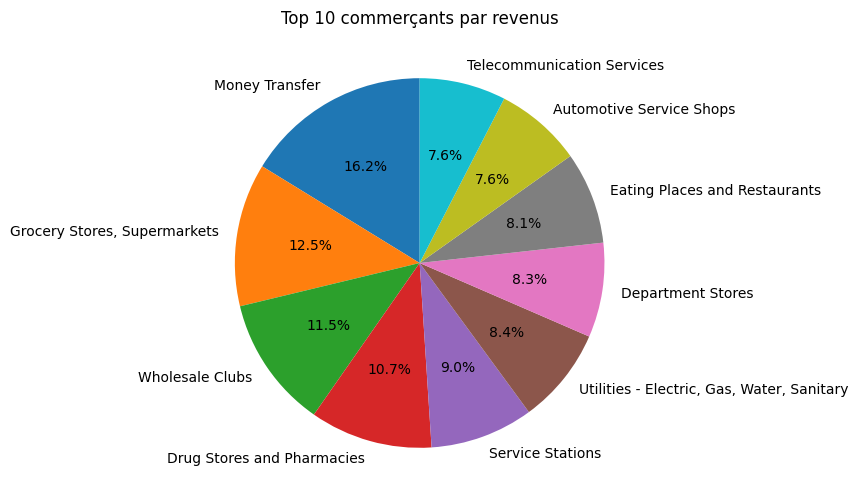

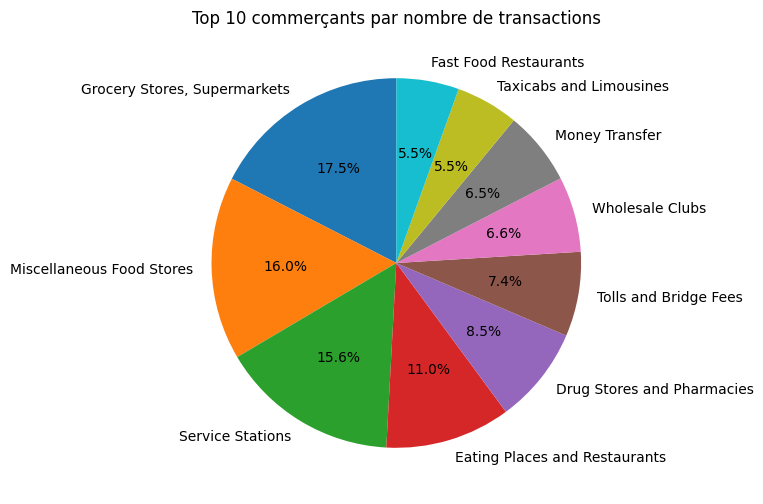

In [14]:
# Assure-toi que 'amount' est bien numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Top 10 commerçants par revenus
top_revenue = df.groupby('description')['amount'].sum().sort_values(ascending=False).head(10)

# Top 10 commerçants par nombre de transactions
top_count = df['description'].value_counts().head(10)

# Diagramme en secteurs – revenus
plt.figure(figsize=(8, 6))
top_revenue.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par revenus')
plt.ylabel('')
plt.show()

# Diagramme en secteurs – nombre de transactions
plt.figure(figsize=(8, 6))
top_count.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par nombre de transactions')
plt.ylabel('')
plt.show()

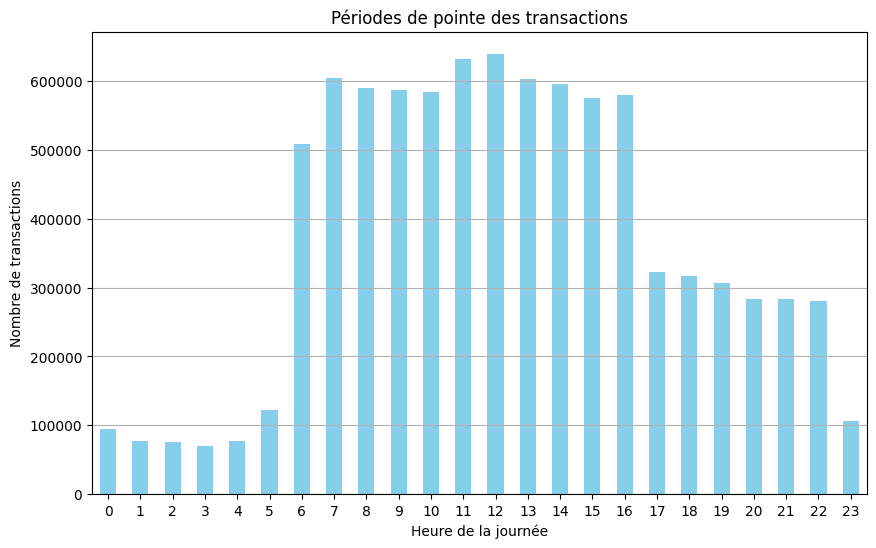

In [15]:
# Histogramme des heures
plt.figure(figsize=(10, 6))
df['heure'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Périodes de pointe des transactions')
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# **2. Analyse d'associations**

#### 2.1 *Transformation des données en données transactionnelles*


In [7]:
# Catégoriser l'heure
def categorize_hour(x):
    if x >= 22 or x < 6:
        return 'late_hour'
    else:
        return 'day_hour'
    
df['hour_category'] = df['heure'].apply(categorize_hour)

# df['Statut'] = df['is_fraud'].apply(lambda x: 'Fraud' if x else 'NoFraud')

# Colonnes pour les transactions
cols_to_use =  ['card_type', 'credit_score_item', 'mcc_category', 'merchant_type', 'amount_category', 'Statut', 'hour_category']



# Gestion des valeurs manquantes
for col in cols_to_use:
    df[col] = df[col].astype(str).fillna('Unknown')

# Création des données transactionnelles (transactions)
def make_transactions(x):
    items = []
    for col in cols_to_use:
        items += x[col].tolist()
    items += x['Statut'].tolist()
    return items 

# Créer les transactions selon l'id de la carte
df_sample = df#.sample(5000) 
transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()

C:\Users\pathy\AppData\Local\Temp\ipykernel_6200\3615947727.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()


In [8]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transactions_df = pd.DataFrame(te_array, columns=te.columns_)
transactions_df

,"Accounting, Auditing, and Bookkeeping Services",Airlines,"Amusement Parks, Carnivals, Circuses",Antique Shops,"Artist Supply Stores, Craft Shops","Athletic Fields, Commercial Sports",Automotive Body Repair Shops,Automotive Parts and Accessories Stores,Automotive Service Shops,Beauty and Barber Shops,...,theatrical_producers,tolls_and_bridge_fees,"tools,_parts,_supplies_manufacturing",travel_agencies,upholstery_and_drapery_stores,"utilities_-_electric,_gas,_water,_sanitary",very_high,welding_repair,wholesale_clubs,women's_ready-to-wear_stores
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2211,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2212,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2213,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2214,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


#### 2.2 *Génération de règles d'association par Apriori et FP-Growth*

In [9]:
# Génération des itemsets fréquents avec Apriori
frequent_itemsets_apriori = apriori(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.2)

# Génération des itemsets fréquents avec FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.2)

# Conversion de frozenset à string pour une meilleure lisibilité
rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

rules_fpgrowth['antecedents'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_fpgrowth['consequents'] = rules_fpgrowth['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

KeyboardInterrupt: 

#### 2.3, 2.4 et 2.5 *Affichage des règles transactionnelles selon les questions*

In [ ]:
# Question 2.3 : MCC et dépenses élevées
import re

mcc_types = df['mcc_category'].unique()
amount_type = df['amount_category'].unique()

mcc_regex = '|'.join([re.escape(x) for x in mcc_types])
amount_regex = 'high|very_high'

rules_mcc_expenses_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(mcc_regex, case=False) &
        rules_apriori['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(amount_regex, case=False) & 
        rules_apriori['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("Règles d'association (MCC et dépenses élevées) - Apriori:")
for idx, row in rules_mcc_expenses_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_mcc_expenses_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(mcc_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(amount_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("\nRègles d'association (MCC et dépenses élevées) - FP-Growth:")
for idx, row in rules_mcc_expenses_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Par la sortie qui suit, on voit que dans notre DataFrame prétraité, il y a des associations entre le type de commerce et les hautes dépenses. Les quatres commerces les plus concernés sont *Automotive Service Shops*, *Departement Stores*, *Miscellaneous Food Stores* et *Services Stations*, où les dépenses varient de hautes à très hautes. Les patterns comportementaux qui ressortent sont que les gens dépensent de grandes sommes dans les magasins départementales, dans les magasins de réparation automobile, dans les magasins de nourriture divers et dans les stations de services.

In [ ]:
# Question 2.4 : Types de cartes et types de commerçants
import re

card_types = df['card_type'].unique()
merchant_types = df['merchant_type'].unique()

# Créer une regex qui matche n'importe quelle valeur
card_regex = '|'.join([re.escape(str(x)) for x in card_types])
merchant_regex = '|'.join([re.escape(str(x)) for x in merchant_types])

rules_card_merchant_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(card_regex, case=False) & 
        rules_apriori['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_apriori['consequents'].str.contains(card_regex, case=False)
    )
]

print("Règles d'association (Types de cartes et types de commerçants) - Apriori:")
for idx, row in rules_card_merchant_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_card_merchant_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(card_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(card_regex, case=False)
    )   
]

print("\nRègles d'association (Types de cartes et types de commerçants) - FP-Growth:")
for idx, row in rules_card_merchant_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Ici, les deux seules associations pertinentes sont entre les commerçants transferant de l'argent et le type de carte *Credit* et entre les libraires et le type de carte *Debit*. Cela nous révèle que les utilisateurs utilisent surtout des cartes de crédit lorsqu'ils veulent transférer de l'argent et des cartes de débit pour acheter des livres.

In [ ]:
# Question 2.5 : Fraude et autres variables
rules_fraud_ap = rules_apriori[
    ( 
        rules_apriori['consequents'].str.contains('Yes', case=False)
    )
]

print("Règles d'association (Fraude et autres variables) - Apriori:")
for idx, row in rules_fraud_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_fraud_fp = rules_fpgrowth[
    ( 
        rules_fpgrowth['consequents'].str.contains('Yes', case=False)
    )
]

print("\nRègles d'association (Fraude et autres variables) - FP-Growth:")
for idx, row in rules_fraud_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

On peut voir qu'on ne trouve aucune corrélation entre les autres variables et la fraude, surtout parce que toutes les règles ne pointent pas vers de la fraude. On peut voir cela par le fait que le lift est supérieur au minimum posé, soit 1.2, signifiant une corrélation positive, surtout les deux premières règles crées par *Apriori*. 

#### 2.6 *Explication et visualisation des métriques associés aux règles*

In [ ]:
rules_mcc_expenses_copy = rules_mcc_expenses_ap.copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    data=rules_mcc_expenses_copy,
    palette='viridis',
    sizes=(50, 300)
)

plt.title('Règles d\'association (MCC et dépenses élevées)')
plt.xlabel('Support')
plt.ylabel('Confiance')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
import networkx

rules_fraud_ap_copy = rules_fraud_ap.copy()

# Graphe orienté
G = networkx.DiGraph()

# Ajouter les arêtes avec les poids basés sur le lift
for idx, row in rules_fraud_ap_copy.iterrows():
    antecedents = [x.strip() for x in row['antecedents'].split(',')]
    consequents = [x.strip() for x in row['consequents'].split(',')]
    for a in antecedents:
        for c in consequents:
            G.add_edge(a, c, weight=row['lift'])

# Taille des arêtes basée sur le lift
edges = G.edges()
weights = [G[u][v]['weight']*2 for u,v in edges]

# Dessiner le graphe
plt.figure(figsize=(12, 8))
pos = networkx.spring_layout(G, k=0.5, seed=42)
networkx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2500, 
        edge_color=weights, width=2, edge_cmap=plt.cm.viridis, arrowsize=20)
plt.title('Réseau des règles d’association : Types de commerces + Dépenses et Fraude')
plt.show()


Le support correspond au pourcentage de *"popularité"* dans le sens que sur 2428 transactions, le pourcentage montré est le nombre de transactions où la règle apparaît le plus souvent. La confiance correspond au pourcentage de *"fiabilité*, soit que par rapport au support, un pourcentage de transactions suit une règle contenant plusieurs arguments à gauche comme un haut crédit, des dépenses basses et la librairie. Le lift correspond à la pertinence de la règle et si la limite posée est dépassée, cela signifie que ce n'est pas par hasard que les arguments de la règle sont associés entre eux (corrélation positive). Si on a un lift égal à la limite, les arguments de la règle sont indépendants (aucune corrélation). Si on a un lift inférieur à la limite, les arguments de la règle n'ont aucun lien entre eux (corrélation négative).

#### 2.7 *Choix du seuil du support minimal*

Pour le seuil de support minimal, on a choisi d'aller avec 0.02, afin de prendre en compte, à la fois les cas spécifiques et les cas généraux, sans avoir trop de bruit dans les données et sans manquer de cas spécifiques. Puisque qu'on est à un peu moins de 10 000 transactions, cette valeur est très justifié. 

(On a pris un échantillon de 10 000 pour des fins de tests. Lancer des millions de transactions dans des algorithmes comme *Apriori* et *FP-Growth* ne ferait que ralentir le processus en plus de causer énormément de bruit dans les résultats)

# **3. Analyse de séquence**

#### 3.1 *Construction des séquences clients*

Comment construire des séquences de transactions par clients ? 
À partir de quelle variable les ordonner ?

Pour construire des séquences client, une solution est d'ordonnancer les transactions par horodatage avec l'attribut `date` qui traduira une évolution dans le temps. Chaque séquence serait constituée d'itemsets formés d'attributs abstraits tels que `amount_category` qui permettent de comparer les comportements plus facilement. Dans ce cas d'étude, l'itemset modèle sera composé de:
- `merchant_type`
- `amount_category`
- `hour_category`
- `Statut`

Par la suite, on se rend compte qu'un itemset avec autant de conditions peut être trop restrictif (support minimale de 1% peu représentatif pour obtenir 3 séquences typiques seulement). Il peut alors être intéressant de se focaliser sur `merchant_type` et d'augmenter la taille de l'échantillon.

In [9]:
features = ['merchant_type', 'amount_category', 'hour_category', 'Statut']
df_seq = df[['card_id','date'] + features].sort_values(['card_id','date']).reset_index(drop='true')

# Pour chaque client, on veut l'ensemble des données ordonnées par horodatage 
sequences = (
    df_seq
    .groupby('card_id')[features[0]]
    .apply(list) # éléments en liste
    .tolist() # de DataFrame à liste
)

print("Nombre de clients et de leurs séquences de transactions: ", len(sequences))
pd.set_option("display.max_colwidth", 100)

Nombre de clients et de leurs séquences de transactions:  2216


Validation...

In [11]:
for i, seq in enumerate(sequences[:3]):
    print(f"Séquence {i+1} (longueur={len(seq)}):")
    for step in seq[:5]: 
        print("  ", step)
    if len(seq) > 5:
        print("  ...")
    print()

Séquence 1 (longueur=3):
   drinking_places_(alcoholic_beverages)
   eating_places_and_restaurants
   automotive_service_shops

Séquence 2 (longueur=4):
   cable,_satellite,_and_other_pay_television_services
   money_transfer
   utilities_-_electric,_gas,_water,_sanitary
   telecommunication_services

Séquence 3 (longueur=11):
   miscellaneous_food_stores
   tools,_parts,_supplies_manufacturing
   money_transfer
   miscellaneous_food_stores
   miscellaneous_home_furnishing_stores
  ...



#### 3.2 *Parcours typiques avec l'algorithme PrefixSpan*

Identifier les parcours clients typiques par projection récursive de préfixes séquentiels.

In [13]:
from prefixspan import PrefixSpan

ps = PrefixSpan(sequences)
ps.minlen, ps.maxlen = 2, 5
# une séquence de 1 item ne fait pas sens,
# pour 10 000 transactions avec environ 2000 clients, 
# on a moins de 5 événements par client en moyenne


support_min = 0.02 # support significatif
motifs = ps.frequent(int(support_min*len(sequences)))

ModuleNotFoundError: No module named 'prefixspan'

#### 3.3 *Parcours d'achat et routine fréquentes*


Sur 10 000 transactions enregistrées dans le jeu de données, 35 séquences typiques sont extraites avec une support relatif de 2% sur les 2515 séquences clientes. Avec cette quantité raisonnable, un tri descendant suffit. Elles concernent toutes des MCC liés à l'alimentaire ou la mobilité et la plus fréquente est `[miscellaneous_food_stores, miscellaneous_food_stores]` avec un support absolu de 191. Plus généralement, on remarque qu'une grande partie de séquences sont des répétitions d'un même type de marchand. 

In [ ]:
motif_df = (
    pd.DataFrame(motifs, columns=['support', 'motif'])
    .sort_values(['support'], ascending=[False])
    .reset_index(drop=True)
)

motif_df

#### 3.4 *Motifs précédant une transaction frauduleuse*

Dans le cadre d'une nouvelle analyse sur la fraude, les séquences seront redéfinies pour inclure le marqueur de fraude et un autre item pour former un itemset `Tuple` qui sera traité pour extraire des motifs précédant une transaction frauduleuse.

In [10]:
# # Aucune fraud ? Fraude artificielle de test
# df_seq.loc[11, 'Statut'] = 'Yes'

df_fraud = (df_seq
           .groupby('card_id', group_keys=False)
           .filter(lambda g: (g['Statut'] == 'Yes').any()))

print("Client Frauduleux:\n\n", df_fraud[['card_id','Statut']], "\n\n\n")

fraud_sequences = (
    df_fraud
    .groupby('card_id')[['merchant_type', 'Statut']]
    .apply(lambda g: list(g.itertuples(index=False, name=None)))
    .tolist()
)

print("Séquences clientes contenant une fraude au moins: \n\n", fraud_sequences, "\n\n\n") 


ps = PrefixSpan(fraud_sequences)
ps.minlen, ps.maxlen = 2, 5

support_min = 0.02 # support significatif
motifs = ps.frequent(int(support_min*len(sequences)))

fraud_motif_df = (
    pd.DataFrame(motifs, columns=['support', 'motif'])
    .sort_values(['support'], ascending=[False])
    .reset_index(drop=True)
)


print("Séquences frauduleuses:\n\n", fraud_motif_df, "\n\n\n")


Client Frauduleux:

       card_id Statut
8852     5497    Yes
8853     5497     No
8854     5497    nan
8855     5497     No
8856     5497    Yes
8857     5497     No
8858     5497    nan 



Séquences clientes contenant une fraude au moins: 

 [[('travel_agencies', 'Yes'), ('wholesale_clubs', 'No'), ('money_transfer', 'nan'), ('motion_picture_theaters', 'No'), ('lighting,_fixtures,_electrical_supplies', 'Yes'), ('wholesale_clubs', 'No'), ('drug_stores_and_pharmacies', 'nan')]] 





c:\Users\pathy\miniconda3\envs\udes_sd_a25\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
c:\Users\pathy\miniconda3\envs\udes_sd_a25\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
c:\Users\pathy\miniconda3\envs\udes_sd_a25\Lib\ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
c:\Users\pathy\miniconda3\envs\udes_sd_a25\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
c:\Users\pathy\miniconda3\envs\udes_sd_a25\Lib\ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; us

NameError: name 'PrefixSpan' is not defined

In [ ]:
len(df_[df["Statut"] == "Yes"])

2

#### 3.5 *Évolutions du comportement*

Dans le cadre d'une étude sur les évolutions de comportements, un échantillon plus conséquent aurait permis une segmentation dans le temps pour faire des comparatifs de séquences fréquentes.

#### 3.6 *Visualisations des comportements transactionnels*

In [ ]:
G = networkx.DiGraph()
for support, motif in motif_df.loc[1:10].itertuples(index=False, name=None):
    for i in range(len(motif)-1):
        # the following has a better representation 
        # with self-loops, but they overlap 
        # G.add_edge(motif[i], motif[i+1], weight=support)
        # thus...
        G.add_edge(motif[i]+f"_{i}", motif[i+1]+f"_{i+1}", weight=support)

pos = networkx.spring_layout(G, seed=42, k=6, iterations=20)

plt.figure(figsize=(16,9))
networkx.draw_networkx(G, pos, with_labels=True, node_size=1200, arrows=True)
networkx.draw_networkx_edge_labels(G, pos, edge_labels=networkx.get_edge_attributes(G, 'weight'), font_size=8)
plt.axis('off');  plt.show()